In [2]:
import pandas as pd

df = pd.read_csv(
    "../data/raw/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"])

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.shape

(5572, 2)

In [4]:
df.columns

Index(['label', 'message'], dtype='str')

In [5]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [6]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [7]:
df[df["label"] == "spam"].head(10)

,label,message
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
5,spam,FreeMsg Hey there darling it's been 3 week's n...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...
11,spam,"SIX chances to win CASH! From 100 to 20,000 po..."
12,spam,URGENT! You have won a 1 week FREE membership ...
15,spam,"XXXMobileMovieClub: To use your credit, click ..."
19,spam,England v Macedonia - dont miss the goals/team...
34,spam,Thanks for your subscription to Ringtone UK yo...
42,spam,07732584351 - Rodger Burns - MSG = We tried to...


In [8]:
df["message_length"] = df["message"].str.len()

In [9]:
df.head()

,label,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [10]:
df.groupby("label")["message_length"].mean()

label
ham      71.482487
spam    138.670683
Name: message_length, dtype: float64

In [11]:
df["message"].str.lower().str.contains("free").sum()

np.int64(265)

In [12]:
df.groupby("label")["message"].apply(
    lambda messages: messages.str.lower().str.contains("free").sum()
)

label
ham      66
spam    199
Name: message, dtype: int64

## Initial observations

- The dataset contains both spam and legitimate messages.
- Spam messages appear to contain certain words such as "free" and "winner" more frequently.
- 265 messages contain the word "free":
  - 66 ham
  - 199 spam
- The presence of "free" appears to be a useful signal, but it cannot be used as a definitive spam rule because legitimate messages can also contain it.

<Axes: xlabel='label'>

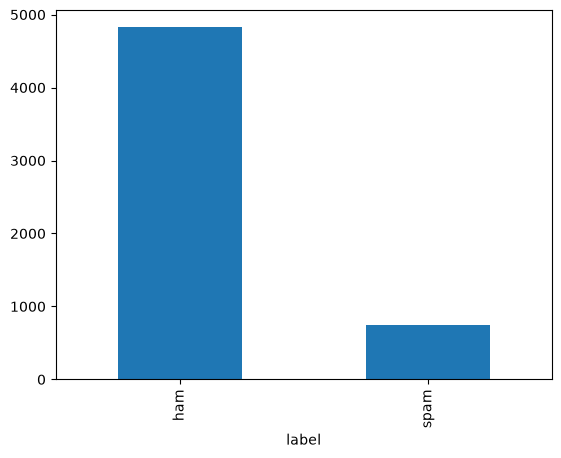

In [13]:
df["label"].value_counts().plot(kind="bar")

In [14]:
df.groupby("label")["message_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,71.482487,58.440652,2.0,33.0,52.0,93.0,910.0
spam,747.0,138.670683,28.873603,13.0,133.0,149.0,157.0,223.0


array([<Axes: title={'center': 'ham'}>, <Axes: title={'center': 'spam'}>],
      dtype=object)

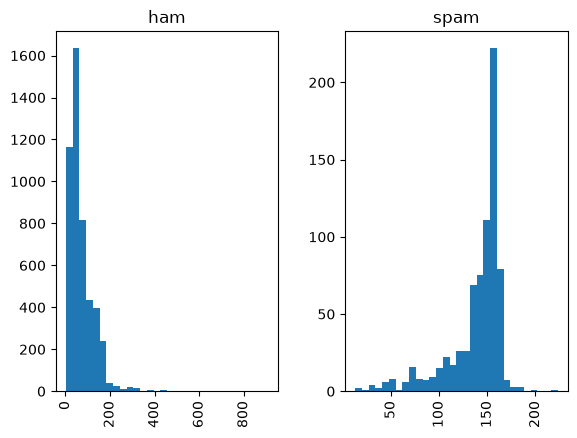

In [16]:
df.hist(column="message_length", by="label", bins=30)

In [ ]:

# Learning how to use CountVectorizer
# X = what we give the model
# y = what we want the model to predict
from sklearn.feature_extraction.text import CountVectorizer

messages = [
    "free prize",
    "free money",
    "hello friend"
]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(messages)
vectorizer.get_feature_names_out()

X.toarray()

array([[1, 0, 0, 0, 1],
       [1, 0, 0, 1, 0],
       [0, 1, 1, 0, 0]])

In [ ]:
# Applying it to our real SMS dataset
# X = what we give the model (number of messages)
# y = what we want the model to predict
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["message"])
X.shape


(5572, 8713)

In [25]:
print(df["message"].iloc[0])

Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...


In [ ]:
print(X[0].toarray())

[[0 0 0 ... 0 0 0]]
